### Feature Relationship Analysis and Dimensionality Assessment

This notebook investigates relationships among the selected neighbourhood vulnerability indicators.

The objectives are:

- Assess variable distributions
- Examine correlations among indicators
- Detect potential multicollinearity
- Standardize variables
- Apply Principal Component Analysis (PCA)
- Determine whether dimensionality reduction is appropriate

The resulting transformed dataset will be used in Notebook 3 for clustering and neighbourhood classification.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### Load neighborhood_profiles_ml_ready file, output from Notebook 1 

In [2]:
df = pd.read_csv(
    "neighbourhood_profiles_ml_ready.csv",
    index_col=0)

df.head()

,LIM_AT,Immigrants,Visible_Minority,Renters,No_Diploma,Bachelors_Degree,Core_Housing_Need,Unaffordable_Housing,Participation_Rate,Employment_Rate,Unemployment_Rate,Lone_Parent_Families
Agincourt North,21.3,19995,26365,1720,6550,4380,2220,34.7,55.4,50.0,9.8,1650
Agincourt South-Malvern West,22.6,15095,20155,2250,4035,4210,1795,38.2,59.0,53.2,9.8,1360
Alderwood,8.2,3970,2490,950,2005,1660,540,21.7,66.5,62.4,6.1,670
Annex,18.3,8270,7270,9870,1585,9135,2420,40.4,70.6,65.8,6.7,895
Banbury-Don Mills,13.7,13195,12700,4735,2295,6500,2115,33.4,59.9,55.6,7.2,1255


### Dataset Verification

The dimensions and data types are verified before conducting statistical analysis.

In [3]:
print("Shape:", df.shape)

df.info()

Shape: (140, 12)
<class 'pandas.core.frame.DataFrame'>
Index: 140 entries, Agincourt North to Yorkdale-Glen Park
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   LIM_AT                140 non-null    float64
 1   Immigrants            140 non-null    int64  
 2   Visible_Minority      140 non-null    int64  
 3   Renters               140 non-null    int64  
 4   No_Diploma            140 non-null    int64  
 5   Bachelors_Degree      140 non-null    int64  
 6   Core_Housing_Need     140 non-null    int64  
 7   Unaffordable_Housing  140 non-null    float64
 8   Participation_Rate    140 non-null    float64
 9   Employment_Rate       140 non-null    float64
 10  Unemployment_Rate     140 non-null    float64
 11  Lone_Parent_Families  140 non-null    int64  
dtypes: float64(5), int64(7)
memory usage: 14.2+ KB


### Descriptive Statistics

Summary statistics provide an overview of the distributions and ranges of each indicator.

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LIM_AT,140.0,19.513571,7.890767,4.5,14.100,18.55,23.950,45.5
Immigrants,140.0,9042.892857,6141.422370,1795.0,4621.250,7502.50,11327.500,31040.0
Visible_Minority,140.0,9899.035714,8355.393100,1100.0,3633.750,7122.50,12505.000,40510.0
Renters,140.0,3755.678571,3008.979559,280.0,1946.250,3232.50,4338.750,23930.0
No_Diploma,140.0,2694.892857,1880.902840,460.0,1423.750,2157.50,3457.500,9560.0
Bachelors_Degree,140.0,3819.000000,3046.742287,445.0,2053.750,3257.50,4385.000,27280.0
Core_Housing_Need,140.0,1720.142857,1002.878222,115.0,967.500,1432.50,2287.500,5335.0
Unaffordable_Housing,140.0,35.072143,6.939441,17.5,31.075,35.60,38.525,56.5
Participation_Rate,140.0,64.547857,6.109557,52.2,59.875,63.60,69.125,86.6
Employment_Rate,140.0,59.272143,6.515583,47.3,54.675,58.55,64.300,82.7


### Indicator Distributions

Histograms are used to examine the distribution of each selected indicator and identify potential skewness, outliers, and non-normality.

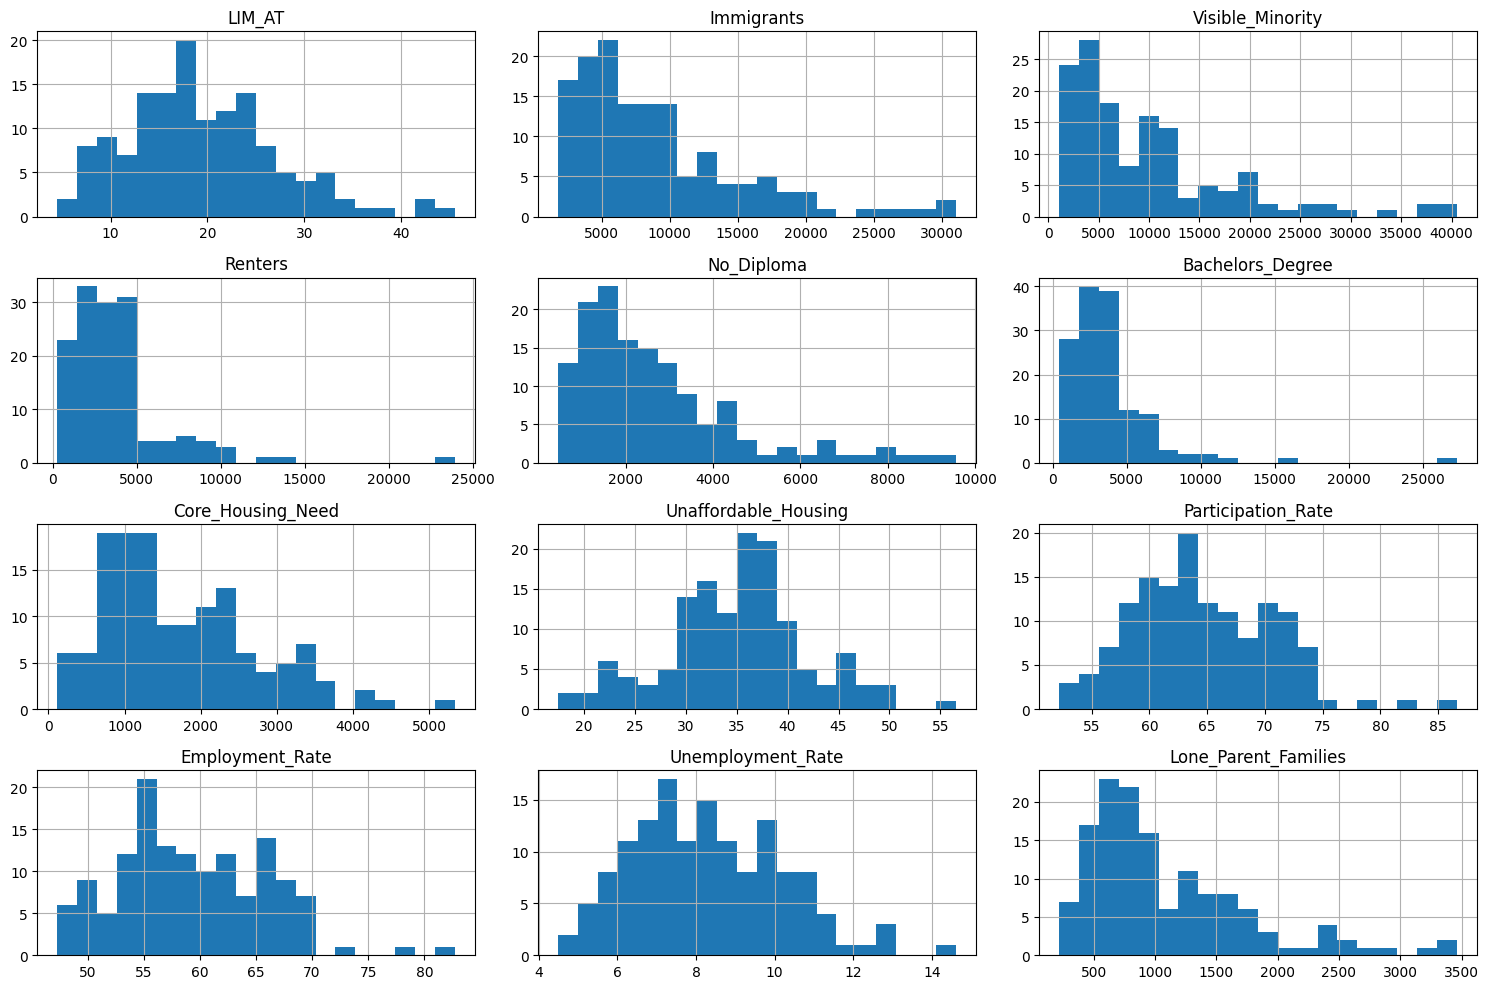

In [6]:
df.hist(
    figsize=(15,10),
    bins=20)

plt.tight_layout()
plt.show()

### DIstribution Assesment: 
The selected indicators exhibit varying degrees of positive skewness, particularly for population count variables such as Immigrants, Visible Minority, Renters, and Bachelor's Degree holders. Because PCA is sensitive to scale differences, all variables will be standardized prior to dimensionality reduction. Standardization mitigates the impact of differing measurement units and variable magnitudes while preserving underlying relationships among indicators.
Following appear reasonably bell-shaped and symmetric:
Participation_Rate
Employment_Rate
Unemployment_Rate
LIM_AT
These variables should behave well in correlation analysis and PCA after standardization.

Moderately Right-Skewed Variables
Lone_Parent_Families
No_Diploma
Core_Housing_Need
This is expected because a small number of neighbourhoods experience substantially higher vulnerability levels than most others.

Strongly Right-Skewed Variables
These show substantial positive skewness:
Immigrants
Visible_Minority
Renters
Bachelors_Degree

### Correlation Analysis

Pearson correlation coefficients are calculated to identify relationships among the selected indicators and assess potential multicollinearity.

In [7]:
corr_matrix = df.corr()

corr_matrix

,LIM_AT,Immigrants,Visible_Minority,Renters,No_Diploma,Bachelors_Degree,Core_Housing_Need,Unaffordable_Housing,Participation_Rate,Employment_Rate,Unemployment_Rate,Lone_Parent_Families
LIM_AT,1.000000,0.349547,0.407557,0.331016,0.290607,-0.013316,0.551192,0.775049,-0.392254,-0.472517,0.734506,0.335386
Immigrants,0.349547,1.000000,0.965324,0.464937,0.768485,0.517912,0.811640,0.364541,-0.350904,-0.375716,0.405817,0.878987
Visible_Minority,0.407557,0.965324,1.000000,0.402670,0.767977,0.449713,0.755323,0.359485,-0.381773,-0.416668,0.486384,0.855924
Renters,0.331016,0.464937,0.402670,1.000000,0.162225,0.815097,0.741258,0.516516,0.349540,0.307182,-0.002591,0.369766
No_Diploma,0.290607,0.768485,0.767977,0.162225,1.000000,0.052908,0.671686,0.123890,-0.436402,-0.461476,0.470333,0.897220
Bachelors_Degree,-0.013316,0.517912,0.449713,0.815097,0.052908,1.000000,0.513960,0.262715,0.371379,0.371195,-0.245499,0.282437
Core_Housing_Need,0.551192,0.811640,0.755323,0.741258,0.671686,0.513960,1.000000,0.549792,-0.118018,-0.172922,0.403875,0.809534
Unaffordable_Housing,0.775049,0.364541,0.359485,0.516516,0.123890,0.262715,0.549792,1.000000,-0.063175,-0.127689,0.399447,0.213184
Participation_Rate,-0.392254,-0.350904,-0.381773,0.349540,-0.436402,0.371379,-0.118018,-0.063175,1.000000,0.990743,-0.671988,-0.368625
Employment_Rate,-0.472517,-0.375716,-0.416668,0.307182,-0.461476,0.371195,-0.172922,-0.127689,0.990743,1.000000,-0.765290,-0.403743


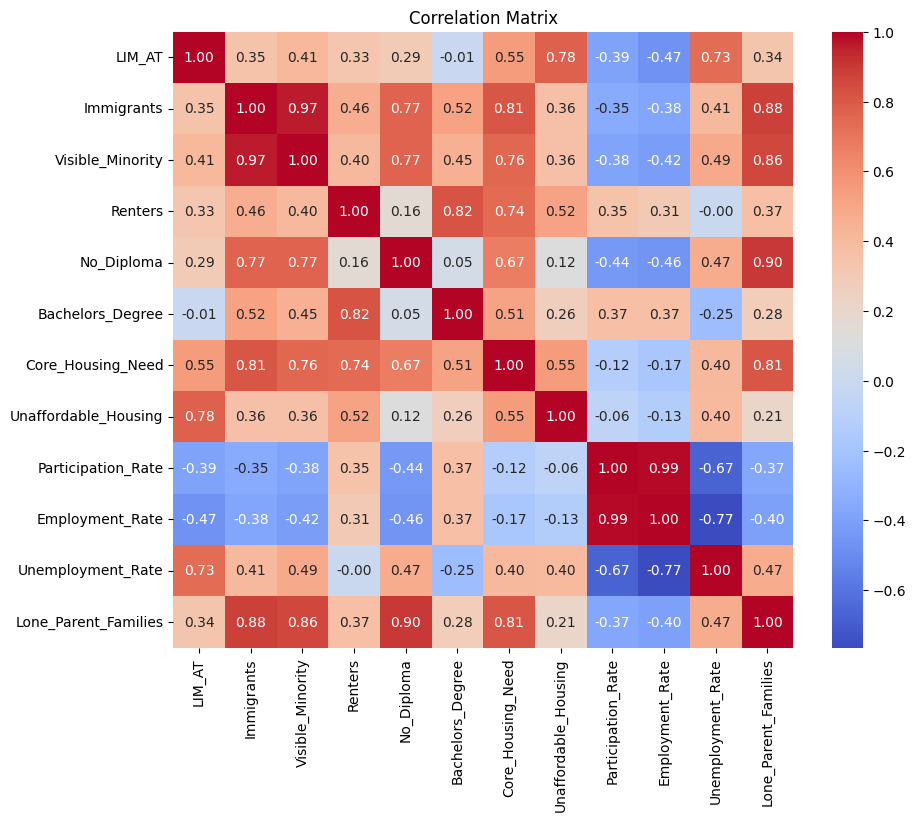

In [8]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

### Correlation Analysis

Several indicators exhibit strong positive correlations, suggesting the presence of multicollinearity within the dataset.

Notable relationships include:

- Immigrants and Visible Minority (r = 0.97)
- Lone Parent Families and No Diploma (r = 0.90)
- Core Housing Need and Lone Parent Families (r = 0.81)
- LIM_AT and Core Housing Need (r = 0.81)

These findings indicate that multiple variables may be capturing similar dimensions of neighbourhood vulnerability. Consequently, dimensionality reduction techniques such as Principal Component Analysis (PCA) are appropriate for identifying latent vulnerability structures while reducing redundancy among indicators.

### Variance Inflation Factor (VIF)

Variance Inflation Factors are calculated to quantify multicollinearity among the selected indicators. Higher VIF values indicate variables that may contain redundant information.

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()

vif_df["Variable"] = df.columns

vif_df["VIF"] = [
    variance_inflation_factor(df.values, i)
    for i in range(df.shape[1])]

vif_df.sort_values("VIF", ascending=False)

,Variable,VIF
8,Participation_Rate,82222.574071
9,Employment_Rate,72431.257150
10,Unemployment_Rate,451.423846
1,Immigrants,142.151604
7,Unaffordable_Housing,126.318393
6,Core_Housing_Need,73.069198
0,LIM_AT,60.175077
2,Visible_Minority,55.788292
11,Lone_Parent_Families,49.952634
3,Renters,40.311917


### Interpretation of VIF Results

Variance Inflation Factors indicate substantial multicollinearity among the selected indicators. All variables exhibit VIF values greater than 10, with several exceeding 50.

The highest VIF values were observed for Participation Rate, Employment Rate, and Unemployment Rate, suggesting that these indicators capture overlapping labour-market characteristics. Similar redundancy is observed among income, immigration, housing, and education-related variables.

Given the presence of strong multicollinearity, dimensionality reduction techniques such as Principal Component Analysis (PCA) are appropriate for reducing redundancy while preserving the underlying socioeconomic information contained within the dataset.

Consequently, all indicators are retained for subsequent PCA and clustering analyses rather than being removed individually.

## Conclusions

Descriptive statistics, distribution analysis, correlation analysis, and Variance Inflation Factor (VIF) assessment were conducted on the selected neighbourhood vulnerability indicators.

The results revealed substantial variability across Toronto neighbourhoods and identified strong relationships among several indicators. Correlation and VIF analyses confirmed the presence of severe multicollinearity, indicating that multiple variables capture overlapping socioeconomic dimensions.

Given these findings, dimensionality reduction techniques are appropriate for reducing redundancy while preserving the information contained within the dataset.

The cleaned and validated dataset is exported for Principal Component Analysis (PCA) and clustering procedures in Notebook 3.

In [11]:
df.to_csv("toronto_neighbourhood_analysis_v2.csv",
    index=True)

print("Notebook 3 dataset exported successfully.")

Notebook 3 dataset exported successfully.


In [15]:
print(df.shape)
print(df.isnull().sum().sum())

(140, 12)
0
